# Phase 2 — Markowitz Baselines & Leakage-Free Walk-Forward Backtesting

**Purpose:** This notebook is *evidentiary*, not exploratory. It demonstrates that the Phase 2
backtesting framework is leakage-free (P4), and establishes the constrained baseline results
that every Phase 4 ML model must beat **net of transaction costs, out-of-sample**.

| Problem | What this notebook shows |
|---------|--------------------------|
| **P1** | Optimized (min-var / max-Sharpe) vs naive 1/N under realistic constraints — how much does optimization actually buy, once costs are paid? |
| **P3** | Drawdowns and equity curves through the COVID-2020 crash and 2022 rate shock (ETF universe) |
| **P4** | The walk-forward engine's no-lookahead guarantees, and the Deflated Sharpe Ratio correcting for the number of strategies tried |

**Data caveats (stated up front, per project honesty rules):**
- The 9-asset universe starts **mid-2021** (BVC free-source limit — a *rolling* ~5-year window),
  so it excludes the COVID crash. The dual-universe design exists precisely to compensate:
  the 5-ETF universe covers 2017→today including both crises.
- **Currency:** BVC returns are MAD-denominated, ETF returns USD. Returns are unitless so the
  arithmetic is valid, but portfolio results embed an **unhedged USD/MAD exposure**. This is
  documented, not corrected — an FX-hedging model is out of scope.
- Risk-free rate is 0 (MVP simplification, parameterized for Phase 5).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if (Path.cwd() / '..' / 'src').resolve().exists() else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))

from backtest import build_cost_vector, run_backtest
from metrics import annualized_sharpe, max_drawdown, summarize
from strategies import EqualWeight, MaxSharpe, MinVariance
from utils import load_params

plt.rcParams['figure.dpi'] = 100
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

P = load_params()['backtest']
UNIVERSES = {}
for name, path in P['universes'].items():
    df = pd.read_parquet(ROOT / path)
    df.index = pd.to_datetime(df.index)
    UNIVERSES[name] = df
    print(f"{name}: {df.shape[0]} days x {df.shape[1]} assets   {df.index.min().date()} -> {df.index.max().date()}")

etf_2017: 2477 days x 5 assets   2017-01-04 -> 2026-07-02
full_2021: 1305 days x 9 assets   2021-07-02 -> 2026-07-02


## 1. The walk-forward engine — and why its numbers can be trusted (P4)

Every result below comes from `src/backtest.py::run_backtest`, an **expanding-window
walk-forward** engine in which the *engine* is the trust boundary, not the strategy:

1. At each month-end rebalance date τ, the engine slices `returns.loc[:τ]` **before** calling
   `strategy.fit` — a strategy physically cannot see the future.
2. New weights earn returns **from τ+1** (fitting and trading at the same close would be a
   subtle lookahead), and the transaction cost of moving from the *drifted* previous weights to
   the new targets is deducted from the τ+1 return.
3. Between rebalances, weights **drift** with returns — turnover is measured against the
   drifted portfolio, exactly as a real book would experience it.
4. Log-returns are converted to simple returns before aggregation (a weighted sum of
   log-returns is *not* a portfolio return).

These are not claims; they are **tested** (`tests/test_backtest.py`):
- `test_engine_never_passes_future_data` — a spy strategy records what it was shown; every
  train window ends on or before its rebalance date.
- `test_perfect_foresight_collapses_inside_engine` — a deliberately cheating strategy with an
  out-of-band channel to the full dataset earns an astronomical Sharpe when fed the future by
  hand, and collapses to noise when run through the engine. **The engine, not good intentions,
  prevents lookahead.**
- `test_new_weights_earn_returns_from_next_day_not_rebalance_day`,
  `test_turnover_measured_against_drifted_not_target_weights`,
  `test_portfolio_return_uses_simple_not_log_aggregation` — hand-computed examples locking in
  the mechanics above.

In [2]:
# Run all baselines on both universes (same code path as src/run_backtest.py)
STRATEGIES = [
    EqualWeight(),
    MinVariance(max_weight=P['max_weight']),
    MaxSharpe(max_weight=P['max_weight'], risk_free_annual=P['risk_free_annual']),
]

RESULTS = {}
for uni_name, returns in UNIVERSES.items():
    costs = build_cost_vector(returns.columns,
                              etf_cost_bps=P['costs_bps']['etf'],
                              bvc_cost_bps=P['costs_bps']['bvc'])
    RESULTS[uni_name] = [
        run_backtest(returns, s,
                     rebalance_freq=P['rebalance_freq'],
                     min_train_days=P['min_train_days'],
                     cost_bps=costs, universe_name=uni_name)
        for s in STRATEGIES
    ]
print('6 backtests complete.')

6 backtests complete.


## 2. Universe A — 5 ETFs, 2017→today: performance through two crises (P3)

This universe exists to recover the crisis evidence the BVC data gap removes: the COVID-2020
crash and the 2022 rate shock are both inside the out-of-sample window. Watch the drawdown
panels: crises are where diversification breaks (P3) and where strategy differences matter.

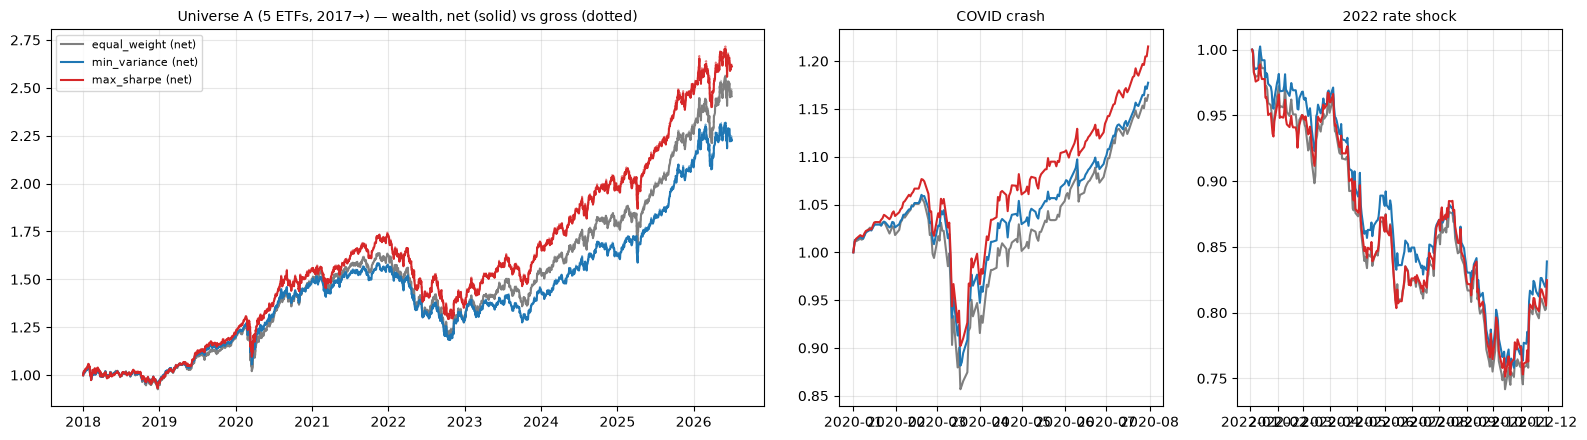

In [3]:
COLORS = {'equal_weight': 'tab:gray', 'min_variance': 'tab:blue', 'max_sharpe': 'tab:red'}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5),
                         gridspec_kw={'width_ratios': [2.2, 1, 1]})
for r in RESULTS['etf_2017']:
    wealth_net = (1 + r.net_returns).cumprod()
    wealth_gross = (1 + r.gross_returns).cumprod()
    axes[0].plot(wealth_net, label=f'{r.strategy_name} (net)', color=COLORS[r.strategy_name])
    axes[0].plot(wealth_gross, ls=':', alpha=0.6, color=COLORS[r.strategy_name])
    for ax, (lo, hi, title) in zip(axes[1:], [('2020-01', '2020-07', 'COVID crash'),
                                              ('2022-01', '2022-11', '2022 rate shock')]):
        seg = wealth_net.loc[lo:hi]
        ax.plot(seg / seg.iloc[0], color=COLORS[r.strategy_name])
        ax.set_title(title, fontsize=10)
axes[0].set_title('Universe A (5 ETFs, 2017→) — wealth, net (solid) vs gross (dotted)', fontsize=10)
axes[0].legend(fontsize=8)
for ax in axes: ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. Universe B — 9 assets, 2021→today, and the side-by-side comparison

The full EURAFRIC-relevant portfolio (4 BVC equities + 5 ETFs), on its shorter window.

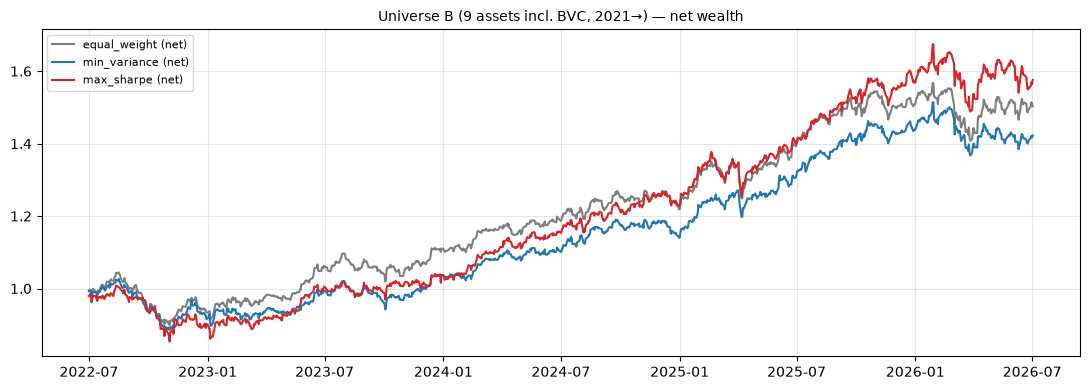

sharpe_net  sharpe_gross  max_dd_net  avg_turnover  \
universe  strategy                                                           
etf_2017  equal_weight      0.8535        0.8567     -0.2656        0.0359   
          min_variance      0.8485        0.8528     -0.2527        0.0424   
          max_sharpe        0.9550        0.9597     -0.2562        0.0485   
full_2021 equal_weight      1.0412        1.0539     -0.1398        0.0534   
          min_variance      0.9645        0.9832     -0.1370        0.0745   
          max_sharpe        1.0107        1.0538     -0.1532        0.1858   

                        total_cost_drag  
universe  strategy                       
etf_2017  equal_weight           0.0037  
          min_variance           0.0044  
          max_sharpe             0.0050  
full_2021 equal_weight           0.0050  
          min_variance           0.0071  
          max_sharpe             0.0197

In [4]:
fig, ax = plt.subplots(figsize=(11, 4))
for r in RESULTS['full_2021']:
    ax.plot((1 + r.net_returns).cumprod(), label=f'{r.strategy_name} (net)',
            color=COLORS[r.strategy_name])
ax.set_title('Universe B (9 assets incl. BVC, 2021→) — net wealth', fontsize=10)
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

rows = []
for uni_name, results in RESULTS.items():
    for r in results:
        rows.append({
            'universe': uni_name, 'strategy': r.strategy_name,
            'sharpe_net': annualized_sharpe(r.net_returns),
            'sharpe_gross': annualized_sharpe(r.gross_returns),
            'max_dd_net': max_drawdown(r.net_returns),
            'avg_turnover': float(r.turnover.mean()),
            'total_cost_drag': float((r.gross_returns - r.net_returns).sum()),
        })
comparison = pd.DataFrame(rows).set_index(['universe', 'strategy'])
comparison

## 4. What the constraints do — concentration vs the cap (P1)

Minimum-variance with **no cap** concentrates into whatever looked safest in the training
window — the classic P1 symptom (noisy covariance → corner solutions). The 25% cap forces
diversification. Compare the two weight histories.

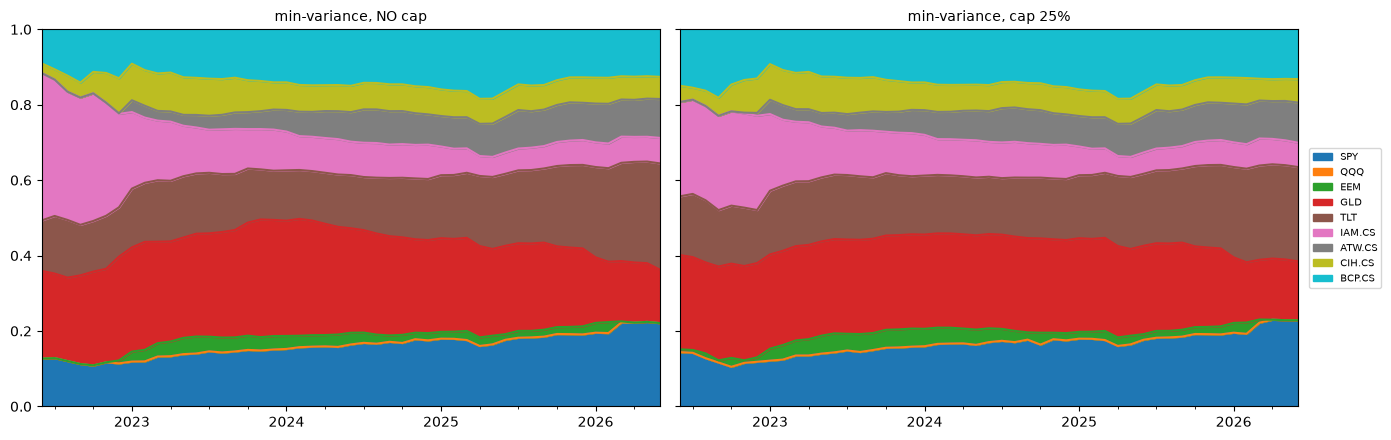

Max single-asset weight ever taken - uncapped: 39.1%, capped: 25.0%


In [5]:
uncapped = [run_backtest(UNIVERSES['full_2021'], MinVariance(max_weight=1.0),
                         rebalance_freq=P['rebalance_freq'],
                         min_train_days=P['min_train_days'],
                         cost_bps=0.0, universe_name='full_2021')][0]
capped = next(r for r in RESULTS['full_2021'] if r.strategy_name == 'min_variance')

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for ax, res, title in [(axes[0], uncapped, 'min-variance, NO cap'),
                       (axes[1], capped, f"min-variance, cap {P['max_weight']:.0%}")]:
    res.target_weights.plot.area(ax=ax, legend=False, colormap='tab10')
    ax.set_title(title, fontsize=10); ax.set_ylim(0, 1)
axes[1].legend(fontsize=7, loc='center left', bbox_to_anchor=(1.01, 0.5))
plt.tight_layout(); plt.show()

print(f"Max single-asset weight ever taken - uncapped: {uncapped.target_weights.max().max():.1%}, "
      f"capped: {capped.target_weights.max().max():.1%}")

## 5. Transaction costs — where optimized strategies pay their bill

Costs (10bps ETFs / 30bps BVC per side, applied to turnover) are inside the backtest, not an
afterthought. The question that matters: **does any ranking flip between gross and net?** A
strategy that wins gross and loses net is a finding — it means its edge is smaller than its
trading bill.

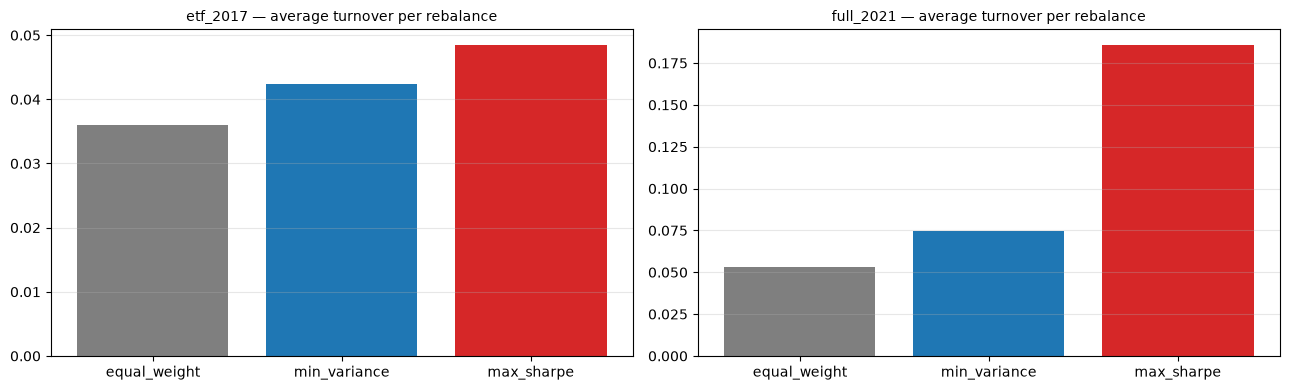

etf_2017: gross ranking ['max_sharpe', 'equal_weight', 'min_variance']
           net ranking   ['max_sharpe', 'equal_weight', 'min_variance']   (no flip)
full_2021: gross ranking ['equal_weight', 'max_sharpe', 'min_variance']
           net ranking   ['equal_weight', 'max_sharpe', 'min_variance']   (no flip)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (uni_name, results) in zip(axes, RESULTS.items()):
    names = [r.strategy_name for r in results]
    ax.bar(names, [float(r.turnover.mean()) for r in results],
           color=[COLORS[n] for n in names])
    ax.set_title(f'{uni_name} — average turnover per rebalance', fontsize=10)
    ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

for uni_name, results in RESULTS.items():
    gross_rank = sorted(results, key=lambda r: -annualized_sharpe(r.gross_returns))
    net_rank = sorted(results, key=lambda r: -annualized_sharpe(r.net_returns))
    flip = [g.strategy_name for g in gross_rank] != [n.strategy_name for n in net_rank]
    print(f"{uni_name}: gross ranking {[r.strategy_name for r in gross_rank]}")
    print(f"{'':>10} net ranking   {[r.strategy_name for r in net_rank]}"
          f"   {'<- RANKING FLIPS NET OF COSTS' if flip else '(no flip)'}")

## 6. Full metrics panel, including the Deflated Sharpe Ratio (P4)

The DSR (Bailey & López de Prado 2014) answers: *given that we tried N strategies and are
looking at this one's Sharpe, what is the probability the Sharpe is genuinely positive rather
than a selection artifact?* Here **N = 3 per universe** (every strategy in this comparison,
logged to MLflow as `n_trials`). With N this small the DSR is directional, not precise —
Phase 5's purged cross-validation will supply better trial populations.

In [7]:
panels = []
for uni_name, results in RESULTS.items():
    trial_sharpes = [float(r.net_returns.mean() / r.net_returns.std()) for r in results]
    ew_net = next(r for r in results if r.strategy_name == 'equal_weight').net_returns
    for r in results:
        panel = summarize(r.net_returns, r.gross_returns, r.turnover,
                          benchmark_net=ew_net if r.strategy_name != 'equal_weight' else None,
                          trial_sharpes=trial_sharpes,
                          risk_free_annual=P['risk_free_annual'])
        panel['universe'], panel['strategy'] = uni_name, r.strategy_name
        panels.append(panel)
metrics_table = pd.DataFrame(panels).set_index(['universe', 'strategy'])
metrics_table[['ann_return_net', 'sharpe_net', 'sharpe_gross', 'max_drawdown_net',
               'calmar_net', 'avg_turnover', 'information_ratio_net', 'dsr_net', 'n_trials']]

ann_return_net  sharpe_net  sharpe_gross  \
universe  strategy                                                 
etf_2017  equal_weight          0.1074      0.8535        0.8567   
          min_variance          0.0951      0.8485        0.8528   
          max_sharpe            0.1151      0.9550        0.9597   
full_2021 equal_weight          0.1032      1.0412        1.0539   
          min_variance          0.0886      0.9645        0.9832   
          max_sharpe            0.1159      1.0107        1.0538   

                        max_drawdown_net  calmar_net  avg_turnover  \
universe  strategy                                                   
etf_2017  equal_weight           -0.2656      0.4045        0.0359   
          min_variance           -0.2527      0.3764        0.0424   
          max_sharpe             -0.2562      0.4493        0.0485   
full_2021 equal_weight           -0.1398      0.7385        0.0534   
          min_variance           -0.1370      0.6470        0.0745   
          max_sharpe             -0.1532      0.7570        0.1858   

                        information_ratio_net  dsr_net  n_trials  
universe  strategy                                                
etf_2017  equal_weight                    NaN   0.9907    3.0000  
          min_variance                -0.4283   0.9903    3.0000  
          max_sharpe                   0.1998   0.9961    3.0000  
full_2021 equal_weight                    NaN   0.9788    3.0000  
          min_variance                -0.3625   0.9694    3.0000  
          max_sharpe                   0.2229   0.9753    3.0000

## 7. Summary — the hurdle Phase 4 must clear

**The baseline to beat is written down here, once, so it cannot drift later:** the best
net-of-cost Sharpe in the table above, per universe, is the number a Phase 4 ML strategy
(HMM-regime-conditioned weights, dynamic covariance) must exceed on the *same engine, same
constraints, same costs* to justify its complexity. If it cannot, the honest conclusion is
that 1/N or a constrained Markowitz baseline is the better product — DeMiguel et al. (2009)
predict exactly that outcome for optimization based on noisy sample moments (P1).

**Limitations restated (do not let slides forget them):**
- Universe B excludes COVID (BVC rolling-window gap); crisis evidence for the 9-asset
  portfolio rests on 2022 only. Universe A carries the COVID evidence.
- Results embed unhedged USD/MAD exposure (documented §1).
- DSR uses N=3 within-run trials; it does not yet count strategies tried in past sessions.
- rf=0 simplification; first-rebalance turnover=1 (from cash) slightly penalizes the shorter
  Universe B when comparing across universes.